# Plots for data generated from julia code (writers.jl)

The data generated by writers.jl is for incremental kinematics, i.e. kmin $\leq$ k $\leq$ kmax and needs to be manually merged. Alternatively, update the corresponding data_file variables to plot the correct data.

Initialization

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import fixed_quad
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.special import jv
import numpy as np
from pathlib import Path
import shutil

# Plot style and paths
# Use LaTeX rendering if available
if shutil.which("pdflatex") or shutil.which("latex"):
    plt.rcParams["text.usetex"] = True
else:
    plt.rcParams["text.usetex"] = False
    print("⚠️  LaTeX not found. Using matplotlib's built-in math rendering.")

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path().resolve()
DATA_PATH = NOTEBOOK_DIR.parent / "data" / "csv"
PLOT_PATH = NOTEBOOK_DIR.parent / "data" / "plots"
DATA_PATH.mkdir(parents=True, exist_ok=True)
PLOT_PATH.mkdir(parents=True, exist_ok=True)


def read_in_csv(filename):
    # Load numeric columns from a CSV with a single header row.
    data = np.loadtxt(filename, delimiter=",", skiprows=1)
    return data.T


def save_pdf(pdf_name, **kwargs):
    # Normalize filename and save the active figure.
    target = Path(pdf_name)
    if target.suffix.lower() != ".pdf":
        target = target.with_suffix(".pdf")
    # Ensure parent directory exists
    target.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(target, **kwargs)

def ft_2d(kx_vals, vals, rx, kmax=5):
    # Hankel-type transform with J1 Bessel (angular dependence exp(i phi)).
    interp_func = interp1d(
        kx_vals, vals, kind="cubic", bounds_error=False, fill_value="extrapolate"
    )

    def integrand(k_abs):
        j1 = jv(1, rx * k_abs)
        return interp_func(k_abs) * j1 * k_abs

    integral_result, _ = fixed_quad(integrand, 0, kmax, n=120)
    return integral_result / (2 * np.pi)

hbarc = 0.1973269804  # GeV*fm


In [6]:
def plot_evol_O_Y0124(data_file, pdf_name):
    # Real-space evolution curves for Y = 0,1,2,4 with log-log inset.
    r, o_y0, o_y1, o_y2, o_y4 = read_in_csv(data_file)

    r = r * hbarc
    o_y0 = o_y0 / hbarc**2
    o_y1 = o_y1 / hbarc**2
    o_y2 = o_y2 / hbarc**2
    o_y4 = o_y4 / hbarc**2

    fig, ax = plt.subplots()
    ax.plot(r, o_y0, label="Y=0", linestyle="-")
    ax.plot(r, o_y1, label="Y=1", linestyle="--")
    ax.plot(r, o_y2, label="Y=2", linestyle="-.")
    ax.plot(r, o_y4, label="Y=4", linestyle=":")
    ax.set_xlabel(r"$r\ \mathrm{[fm]}$", fontsize=16)
    ax.set_ylabel(r"$O_{-+}(r,Y)\ /\ g^6$  $\mathrm{[fm]}^2$", fontsize=16)
    ax.set_xlim(0, 5.2 * hbarc)
    ax.set_ylim(0 / hbarc**2, 0.0008 / hbarc**2)
    ax.legend(loc="lower right", ncol=2)

    # Log-log inset highlighting the small-r behavior
    ax_inset = inset_axes(ax, width="40%", height="30%", loc="upper left", borderpad=3)
    ax_inset.loglog(r, o_y0, label="Y=0", linestyle="-")
    ax_inset.loglog(r, o_y1, label="Y=1", linestyle="--")
    ax_inset.loglog(r, o_y2, label="Y=2", linestyle="-.")
    ax_inset.loglog(r, o_y4, label="Y=4", linestyle=":")
    ax_inset.set_xlim(0.01 * hbarc, 2.8 * hbarc)
    ax_inset.set_ylim(1e-10 / hbarc**2, 3e-4 / hbarc**2)
    ax_inset.yaxis.set_ticks_position("right")
    mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="gray", lw=1)
    ax_inset.tick_params(axis="both", which="major", labelsize=8)

    save_pdf(pdf_name)
    plt.show()
    return fig, ax


def plot_evol_kT_O_Y4_momspace(data_file, pdf_name):
    # Momentum-space evolution at Y=4 with asymptotic comparison.
    k, o_y4, o_y4_asym = read_in_csv(data_file)

    fig, ax = plt.subplots()
    ax.semilogy(k, o_y4, label="Y=4", linestyle=":", color="C3")
    ax.semilogy(
        k,
        o_y4_asym,
        label=r"$\sim k_\perp^{-4\gamma}$",
        linestyle="--",
        color="black",
    )
    ax.set_xlabel(r"$k_\perp\ \mathrm{[GeV]}$", fontsize=16)
    ax.set_ylabel(
        r"$k_\perp O_{-+}(k_\perp,Y)\ /\ g^6$  $\mathrm{[GeV]}^{-3}$",
        fontsize=16,
    )
    ax.set_xlim(1, 2)
    ax.set_ylim(6e-5, 1.2e-3)
    ax.set_yticks([1e-4, 5e-4, 1e-3])
    ax.legend(loc="upper right")

    plt.tight_layout()
    save_pdf(pdf_name)
    plt.show()
    return fig, ax


def plot_f1f2_refit(
    f1_exp_file,
    f1_pow_file,
    f1_file,
    f2_exp_file,
    f2_pow_file,
    f2_file,
    pdf_name,
):
    # Side-by-side F1/F2 plots sharing the y-axis.
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12.8, 4.8))
    fig.subplots_adjust(wspace=0)

    q2_vals, vals_exp = read_in_csv(f1_exp_file)
    _, vals_pow = read_in_csv(f1_pow_file)
    ax1.plot(q2_vals, vals_exp, linestyle="--", linewidth=2, label="exp.")
    ax1.plot(q2_vals, vals_pow, linestyle="-.", linewidth=2, label="pow.")

    q2_vals, vals = read_in_csv(f1_file)
    ax1.plot(q2_vals, vals, linestyle="-", color="black", label="1707.09063")
    ax1.set_xlabel("$\\Delta_{\\perp}^2$ [GeV]$^2$", fontsize=16)
    ax1.set_title("$F_1(\\Delta_{\\perp}^2)$", fontsize=16)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlim([1e-1, 10])
    ax1.set_xticks([1e-1, 1, 10])
    ax1.set_ylim([1e-3, 2])
    ax1.legend(ncols=3, loc="lower center")

    q2_vals, vals_exp = read_in_csv(f2_exp_file)
    _, vals_pow = read_in_csv(f2_pow_file)
    ax2.plot(q2_vals, vals_exp, linestyle="--", linewidth=2, label="exp.")
    ax2.plot(q2_vals, vals_pow, linestyle="-.", linewidth=2, label="pow.")

    q2_vals, vals = read_in_csv(f2_file)
    ax2.plot(q2_vals, vals, linestyle="-", color="black", label="1707.09063")
    ax2.set_xlabel("$\\Delta_{\\perp}^2$ [GeV]$^2$", fontsize=16)
    ax2.set_title("$F_2(\\Delta_{\\perp}^2)$", fontsize=16)
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position("right")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlim([1e-1, 10])
    ax2.set_xticks([1e-1, 1, 10])
    ax2.set_ylim([1e-3, 2])

    # Avoid overlapping tick labels between subplots
    ax1.get_xticklabels()[-1].set_visible(False)
    ax2.get_xticklabels()[0].set_visible(False)

    plt.subplots_adjust(hspace=0, wspace=0)
    save_pdf(pdf_name, bbox_inches="tight")
    plt.show()
    return fig, (ax1, ax2)


def plot_sivers(data_file, pdf_name, masked=True):
    # Sivers function with log-fit inset (no error bands).
    def model(k, a, b):
        return a * np.log(k / b)

    k_vals, vals_re, _, err_re, _, _, _, _, _, _ = read_in_csv(data_file)

    mN, Nc = 0.93827, 3
    alpha = 0.25
    prf = 8 * mN * Nc / np.pi * alpha**2

    # Fit small-k region for log behavior in the inset
    mask_fit = (k_vals > 0) & (k_vals < 1e-2)
    k_fit = k_vals[mask_fit]
    vals_fit = prf * vals_re[mask_fit] / k_fit
    popt, _ = curve_fit(model, k_fit, vals_fit, p0=[0.08, 0.2])

    if masked:
        mask = k_vals >= 1e-4
        k_vals = k_vals[mask]
        vals_re = vals_re[mask]
        err_re = err_re[mask]

    vals_re = vals_re / k_vals
    vals = prf * vals_re

    # Print fit parameters
    print(f"Log fit parameters: a={popt[0]:.6f}, Qb={popt[1]:.6f}")

    fig, ax = plt.subplots()
    ax.plot(k_vals, vals, linestyle="-", linewidth=2, label="exp.")
    ax.set_xlabel(r"$k_\perp \, \mathrm{[GeV]}$", fontsize=16)
    ax.set_ylabel(
        r"$x\,f_{1\mathrm{T}}^\perp\,(k_\perp) \, \mathrm{[GeV]^{-2}}$",
        fontsize=16,
    )
    ax.set_xlim([0, 1])
    ax.set_yticks([0, -0.1, -0.2, -0.3, -0.4])

    # Inset with log-fit curve
    axins = inset_axes(ax, width="30%", height="20%", loc="lower left")
    k_fit_line = np.linspace(1e-5, 5e-3, 100)
    vals_fit_line = model(k_fit_line, *popt)

    axins.scatter(k_vals, vals, marker=".", zorder=3)
    axins.plot(k_fit_line, vals_fit_line, linestyle="-", linewidth=0.5, color="black")

    axins.set_xticks([2e-3, 4e-3])
    axins.set_yticks([-0.25, -0.35])
    axins.tick_params(axis="x", which="both", top=True, bottom=False, labeltop=True, labelbottom=False)
    axins.tick_params(axis="y", which="both", left=False, right=True, labelleft=False, labelright=True)

    x_min, x_max = 0.9 * k_vals[0], 1.1 * k_vals[3]
    y_min, y_max = -0.4, -0.25
    axins.set_xlim(x_min, x_max)
    axins.set_ylim(y_min, y_max)
    axins.set_yticks([-0.3])

    # Inset for the zero crossing region
    axins0 = inset_axes(ax, width="30%", height="20%", loc="center")
    mark_inset(ax, axins0, loc1=1, loc2=3, fc="none", ec="gray", lw=1)

    x_min, x_max = 0.25, 0.4
    y_min, y_max = -0.019, 0.019
    axins0.set_xticks([0.3, 0.35])
    axins0.set_yticks([0])
    axins0.set_xlim(x_min, x_max)
    axins0.set_ylim(y_min, y_max)

    axins0.plot(k_vals, vals, linestyle="-")
    axins0.axhline(0, color="black", linewidth=0.5)

    save_pdf(pdf_name)
    plt.show()
    return fig, ax


def plot_sivers_pos(data_file, pdf_name):
    # Positive-only log plot for the Sivers function.
    k_vals, vals_re, _, _, _, _, _, _, _, _ = read_in_csv(data_file)

    mN, Nc = 0.93827, 3
    alpha = 0.25
    prf = 8 * mN * Nc / np.pi * alpha**2

    vals_re = vals_re / k_vals
    vals = prf * vals_re

    fig, ax = plt.subplots()
    ax.plot(k_vals, vals, linestyle="-", linewidth=2, label="exp.")
    ax.set_xlabel(r"$k_\perp \, \mathrm{[GeV]}$", fontsize=16)
    ax.set_ylabel(
        r"$x\,f_{{1\mathrm{{T}}}}^\perp\,(k_\perp)\, \mathrm{{[GeV]}}^{{-2}}$ ",
        fontsize=16,
    )
    ax.set_xlim([0.35, 1.2])
    ax.set_xticks([0.4, 0.6, 0.8, 1.0, 1.2])
    ax.set_yscale("log")
    ax.set_ylim([1e-4, 5e-3])

    plt.subplots_adjust(hspace=0, wspace=0)
    save_pdf(pdf_name, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_odderon_dist(data_file, pdf_name, masked=True):
    # Odderon distribution with fitted model curve (no CI band).
    def model(k, norm, a, b, c2):
        return norm * (k / b) ** a * np.log(k / b) * np.exp(-k**2 / (4 * c2))

    k_vals, vals_re, _, _, _, _, _, _, _, _ = read_in_csv(data_file)

    if masked:
        # mask = k_vals >= 5.5e-5
        mask = k_vals >= 1e-4
        k_vals = k_vals[mask]
        vals_re = vals_re[mask]

    popt, _ = curve_fit(model, k_vals, vals_re, p0=[0.01, 1.0, 0.3, 0.2])
    k_fit = np.linspace(k_vals[0], k_vals[-1], 500)
    vals_fit = model(k_fit, *popt)

    # Print fit parameters
    norm, a, Qb, Qc2 = popt
    print(f"Odderon fit parameters: norm={norm:.6e}, a={a:.6f}, Qb={Qb:.6f}, Qc={np.sqrt(Qc2):.6f}")

    fig, ax = plt.subplots()
    ax.plot(k_vals, vals_re, label="Data", linestyle="-", linewidth=2)
    ax.plot(k_fit, vals_fit, label="Fit", linestyle="--", linewidth=2, color="black")
    ax.set_xlabel(r"$k_\perp \, \mathrm{[GeV]}$", fontsize=16)
    ax.set_ylabel(
        r"$k_\perp^2 \, \mathcal{O}_{\Lambda' \Lambda}(k_\perp) / g^6 \, \mathrm{[GeV^{-2}]}$",
        fontsize=16,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim([0, 1])
    ax.legend()

    plt.subplots_adjust(hspace=0, wspace=0)
    save_pdf(pdf_name, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_ft_compare(kspace_file, direct_file, pdf_name, kmax=2.0, r_min=1e-4, r_max=20.0, n_r=100):
    # Compare Fourier-transform result to direct r-space data.
    k_vals, vals_re, _, _, _, _, _, _, _, _ = read_in_csv(kspace_file)
    r_vals = np.linspace(r_min, r_max, n_r)

    vals_re = vals_re / k_vals**2
    ft_vals = np.array([-ft_2d(k_vals, vals_re, r, kmax=kmax) for r in r_vals])
    r_vals_plot = r_vals * hbarc

    fig, ax = plt.subplots()
    ax.plot(r_vals_plot, ft_vals, linestyle="-", linewidth=2, label="FT")

    r_direct, vals_direct, _, _, _, _, _, _, _, _ = read_in_csv(direct_file)
    r_direct = r_direct * hbarc
    ax.plot(r_direct, vals_direct, linestyle="-", linewidth=2, label="Direct")

    ax.set_xlabel("$r$ [fm]", fontsize=14)
    ax.set_ylabel("$\\mathcal{O}(r,\\Delta=0)$", fontsize=14)
    ax.legend()

    plt.tight_layout()
    save_pdf(pdf_name)
    plt.show()
    return fig, ax

# Plots of Dirac and Pauli form factors, spin-dependent Odderon and Sivers function

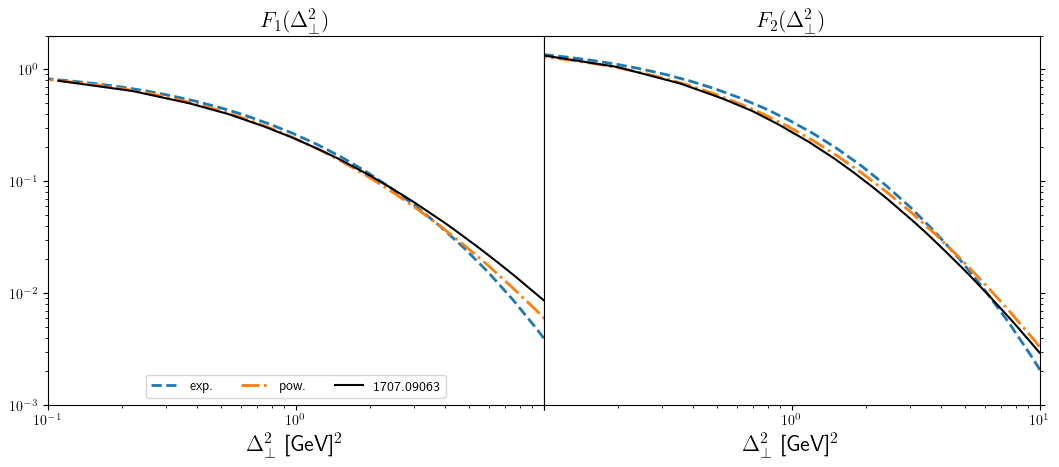

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: title={'center': '$F_1(\\Delta_{\\perp}^2)$'}, xlabel='$\\Delta_{\\perp}^2$ [GeV]$^2$'>,
  <Axes: title={'center': '$F_2(\\Delta_{\\perp}^2)$'}, xlabel='$\\Delta_{\\perp}^2$ [GeV]$^2$'>))

In [3]:
plot_f1f2_refit(
    DATA_PATH / "exp" / "f1_data.csv",
    DATA_PATH / "pow" / "f1_data.csv",
    DATA_PATH / "1707.09063" / "f1_data.csv",
    DATA_PATH / "exp" / "f2_data.csv",
    DATA_PATH / "pow" / "f2_data.csv",
    DATA_PATH / "1707.09063" / "f2_data.csv",
    PLOT_PATH / "exp" / "F1F2_refit.pdf",
)

Odderon fit parameters: norm=2.933743e-02, a=0.901348, Qb=0.332723, Qc=0.232063


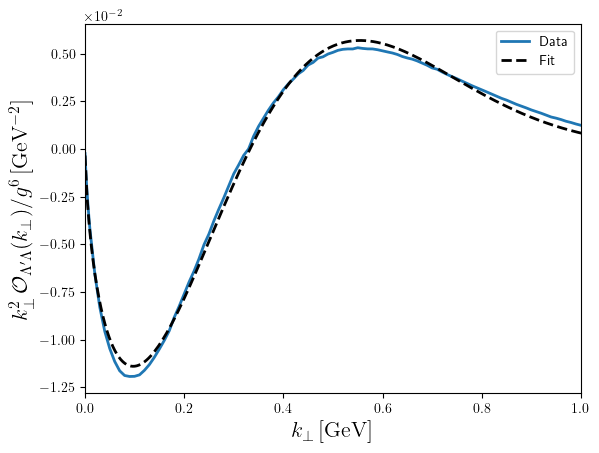

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$k_\\perp \\, \\mathrm{[GeV]}$', ylabel="$k_\\perp^2 \\, \\mathcal{O}_{\\Lambda' \\Lambda}(k_\\perp) / g^6 \\, \\mathrm{[GeV^{-2}]}$">)

In [ ]:
plot_odderon_dist(
    DATA_PATH / "exp" / "output_odderon_vegas_0.0_merged.csv",
    PLOT_PATH / "exp" / "odderon_dist_vegas_mu_0.0.pdf",
)

Log fit parameters: a=0.057146, Qb=0.266864


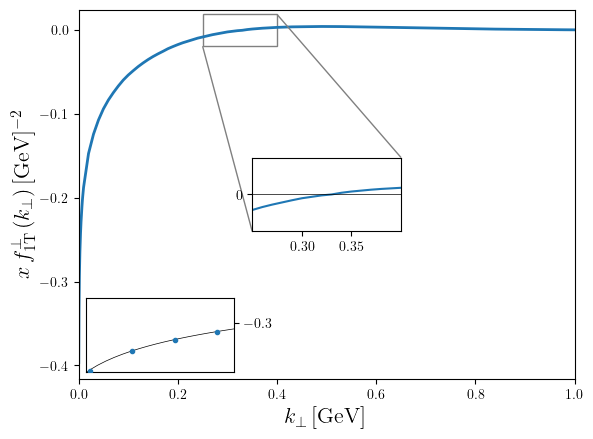

(<Figure size 640x480 with 3 Axes>,
 <Axes: xlabel='$k_\\perp \\, \\mathrm{[GeV]}$', ylabel='$x\\,f_{1\\mathrm{T}}^\\perp\\,(k_\\perp) \\, \\mathrm{[GeV]^{-2}}$'>)

In [ ]:
plot_sivers(
    DATA_PATH / "exp" / "output_odderon_vegas_0.0_merged.csv",
    PLOT_PATH / "exp" / "gluon_sivers_vegas_mu_0.0.pdf",
)

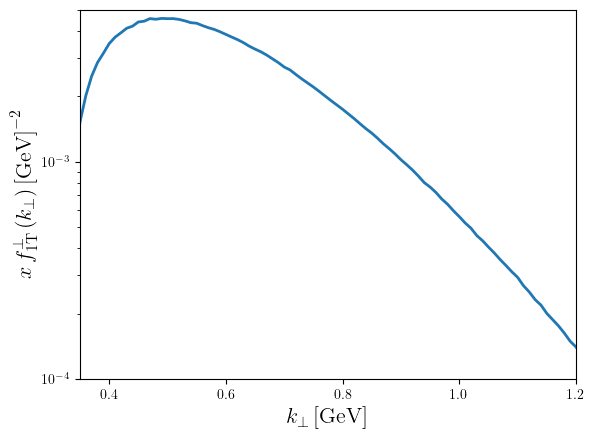

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$k_\\perp \\, \\mathrm{[GeV]}$', ylabel='$x\\,f_{{1\\mathrm{{T}}}}^\\perp\\,(k_\\perp)\\, \\mathrm{{[GeV]}}^{{-2}}$ '>)

In [ ]:
plot_sivers_pos(
    DATA_PATH / "exp" / "output_odderon_vegas_0.0_merged.csv",
    PLOT_PATH / "exp" / "gluon_sivers_vegas_mu_0.0_pos.pdf",
)

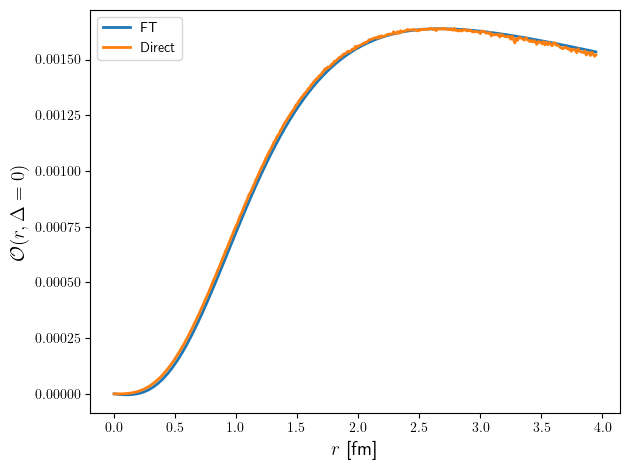

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$r$ [fm]', ylabel='$\\mathcal{O}(r,\\Delta=0)$'>)

In [ ]:
plot_ft_compare(
    DATA_PATH / "exp" / "output_odderon_vegas_0.0_merged.csv",
    DATA_PATH / "exp" / "output_odderon_r_vegas_0.0_merged.csv",
    PLOT_PATH / "exp" / "ft_vs_direct.pdf",
)

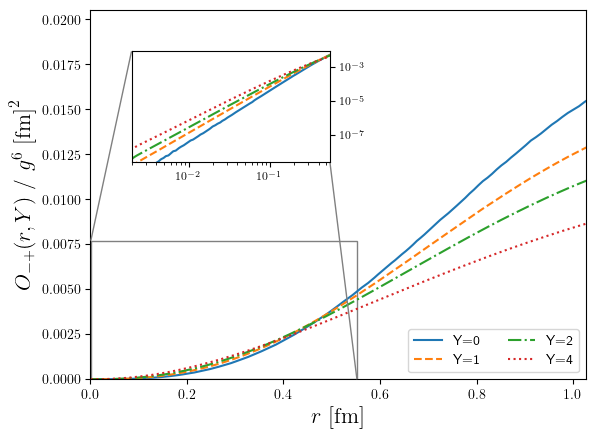

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='$r\\ \\mathrm{[fm]}$', ylabel='$O_{-+}(r,Y)\\ /\\ g^6$  $\\mathrm{[fm]}^2$'>)

In [3]:
plot_evol_O_Y0124(DATA_PATH / "exp" / "evol_O_Y=0124.csv", PLOT_PATH / "exp" / "evol_O_Y=0124.pdf")

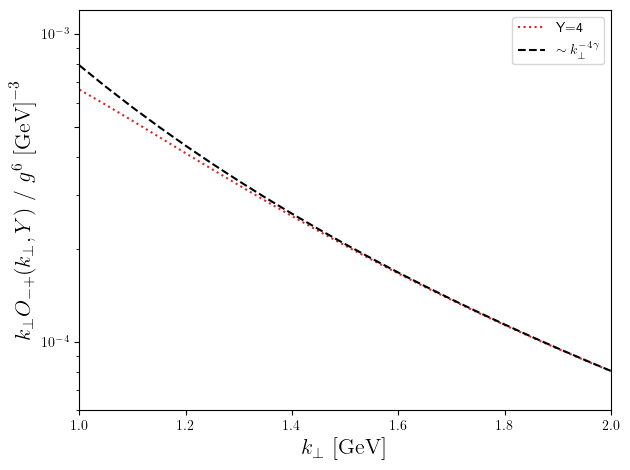

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$k_\\perp\\ \\mathrm{[GeV]}$', ylabel='$k_\\perp O_{-+}(k_\\perp,Y)\\ /\\ g^6$  $\\mathrm{[GeV]}^{-3}$'>)

In [9]:
plot_evol_kT_O_Y4_momspace(
    DATA_PATH / "exp" / "evol_kT_O_Y=4_momspace.csv",
    PLOT_PATH / "exp" / "evol_kT_O_Y=4_momspace.pdf",
)

# Open charm production

In [ ]:
from joblib import Parallel, delayed
from scipy.integrate import nquad

# Physics constants for the open-charm calculation
alpha_s = 0.25
alpha_em = 1 / 137
ec = 2 / 3
mc = 1.275  # GeV
Nc = 3
mN = 0.93827  # GeV


def build_sivers_interpolator(data_file):
    # Interpolate the Sivers function from CSV data.
    k_vals, vals_re, _, _, _, _, _, _, _, _ = read_in_csv(data_file)
    prf = 8 * mN * Nc / np.pi * alpha_s**2
    vals = prf * vals_re
    return interp1d(k_vals, vals, kind="linear", bounds_error=False, fill_value=0)


def AQtilde(kT, interp_sivers):
    # Eq. 8 from 1812.03959
    g2 = 4 * np.pi * alpha_s
    prf = 1 / (Nc * kT**2 * mN / (2 * g2 * np.pi**3))
    return prf * interp_sivers(kT) / kT


def scattering_H(y, z, kT, lT, Q2):
    # Eq. 15 from 1812.03959
    rho = z * (1 - z) * Q2 + mc**2

    lT2 = np.dot(lT, lT)
    l_m_k = lT - kT
    l_m_k2 = np.dot(l_m_k, l_m_k)
    rho_p_l_m_k2 = rho + l_m_k2
    rho_p_lT2 = rho + lT2

    prf = (1 - y + y**2 / 2)
    prf1 = z**2 + (1 - z) ** 2
    term1 = l_m_k / rho_p_l_m_k2 - lT / rho_p_lT2
    prf2 = 4 * (1 - y) * z**2 * (1 - z) ** 2 * Q2
    term2 = 1 / rho_p_l_m_k2 - 1 / rho_p_lT2
    term22 = term2**2
    return prf * (prf1 * np.dot(term1, term1) + mc**2 * term22) + prf2 * term22


def integrand(y, z, Q2, ST, kT, lT, interp_sivers):
    # Scattering kernel times the odderon input (Sivers via AQtilde).
    k_norm = np.sqrt(np.dot(kT, kT))
    s_x_kT = ST[0] * kT[1] - ST[1] * kT[0]
    aqt = AQtilde(k_norm, interp_sivers)
    return scattering_H(y, z, kT, lT, Q2) * s_x_kT * aqt


def dsigma_dkT(xB, y, z, Q2, kT, interp_sivers):
    # Differential cross section d sigma / d kT.
    lmax = 10
    r_l_min = 1e-5
    r_l_max = lmax

    ST = np.array([0, 1])
    prf = alpha_em**2 * ec**2 / (2 * np.pi**4 * xB * Q2) / (2 * np.pi) ** 2
    prf *= 389.379  # Convert to micro-barn / GeV^4

    def func(r, theta):
        return (
            integrand(
                y,
                z,
                Q2,
                ST,
                kT,
                np.array([r * np.cos(theta), r * np.sin(theta)]),
                interp_sivers,
            )
            * r
        )

    res, err = nquad(
        func,
        [(r_l_min, r_l_max), (0, 2 * np.pi)],
        opts=[{"limit": 150, "epsrel": 1e-3}, {"limit": 150, "epsrel": 1e-3}],
    )
    res *= prf
    err *= prf
    return res, err


def plot_open_charm(data_file, pdf_name, xB=0.1, y=0.5, z=0.5, Q2=1.0):
    # Open-charm plot at Q2=1 using the Sivers input from data_file.
    kT_vals = np.linspace(1e-5, 3.5, 256)
    interp_sivers = build_sivers_interpolator(data_file)

    vals_0 = Parallel(n_jobs=-1, backend="loky")(
        delayed(dsigma_dkT)(xB, y, z, Q2, np.array([k, 0]), interp_sivers)
        for k in kT_vals
    )

    fig, ax = plt.subplots()
    ax.plot(kT_vals, [v[0] for v in vals_0], label="This work")
    ax.set_xlim([0, 1.5])
    ax.set_ylabel(r"$\mathrm{d}\sigma \, [\mathrm{mb} \, \mathrm{GeV}^{-4}]$", fontsize=16)
    ax.set_xlabel(r"$k_\perp \, \mathrm{[GeV]}$", fontsize=16)

    plt.subplots_adjust(hspace=0, wspace=0)
    save_pdf(pdf_name, bbox_inches="tight")
    plt.show()
    return fig, ax

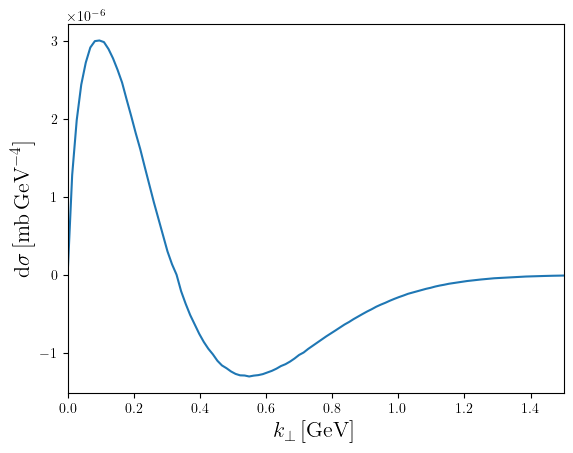

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$k_\\perp \\, \\mathrm{[GeV]}$', ylabel='$\\mathrm{d}\\sigma \\, [\\mathrm{mb} \\, \\mathrm{GeV}^{-4}]$'>)

In [ ]:
plot_open_charm(
    DATA_PATH / "exp" / "output_odderon_vegas_0.0_merged.csv",
    PLOT_PATH / "exp" / "open_charm_Q2_1.pdf",
)
